# Weather ETL Pipeline Using the OpenWeather API

This project demonstrates a simple ETL (Extract, Transform, Load) pipeline using Python. Weather data is extracted from the OpenWeather API for multiple Nigerian cities, transformed into a structured dataset using Pandas, and loaded into a CSV file for analysis.

In [59]:
# Install and Import the Libraries

# !pip install requests pandas
import requests
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

## Extract Weather Data from the OpenWeather API

In [52]:
# OpenWeather API Key
API_KEY = "YOUR_API_KEY"

# Cities to retrieve weather information for
cities = ["Abuja", "Lagos", "Kano", "Lokoja"]

# Empty list to store extracted weather records
weather_records = []

In [53]:
# Loop through each city and extract weather information

for city in cities:

    # API endpoint
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    # Send request to OpenWeather API
    response = requests.get(url)

    # Continue only if the request was successful
    if response.status_code == 200:

        weather_data = response.json()

        # Store only the required information
        record = {
            "City": weather_data["name"],
            "Temperature (°C)": weather_data["main"]["temp"],
            "Humidity (%)": weather_data["main"]["humidity"],
            "Weather Condition": weather_data["weather"][0]["description"].title(),
            "Wind Speed (m/s)": weather_data["wind"]["speed"],
            "Date & Time": datetime.fromtimestamp(weather_data["dt"])
        }

        # Add the record to the list
        weather_records.append(record)

    else:
        print(f"Failed to retrieve data for {city}")

## Transform the Extracted Data

In [54]:
# Convert the extracted data into a Pandas DataFrame
weather_df = pd.DataFrame(weather_records)

weather_df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Abuja,22.03,96,Overcast Clouds,1.00,2026-07-13 20:40:52
1,Lagos,24.44,92,Overcast Clouds,2.76,2026-07-13 20:36:53
2,Kano,30.32,45,Overcast Clouds,2.33,2026-07-13 20:43:48
3,Lokoja,23.30,95,Overcast Clouds,0.92,2026-07-13 20:43:49


In [55]:
# Check for missing values
print(weather_df.isnull().sum())

# Check data types
print(weather_df.dtypes)

City                 0
Temperature (°C)     0
Humidity (%)         0
Weather Condition    0
Wind Speed (m/s)     0
Date & Time          0
dtype: int64
City                         object
Temperature (°C)            float64
Humidity (%)                  int64
Weather Condition            object
Wind Speed (m/s)            float64
Date & Time          datetime64[ns]
dtype: object


In [56]:
# Clean text columns

weather_df["City"] = weather_df["City"].str.strip()
weather_df["Weather Condition"] = weather_df["Weather Condition"].str.strip()

weather_df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Abuja,22.03,96,Overcast Clouds,1.00,2026-07-13 20:40:52
1,Lagos,24.44,92,Overcast Clouds,2.76,2026-07-13 20:36:53
2,Kano,30.32,45,Overcast Clouds,2.33,2026-07-13 20:43:48
3,Lokoja,23.30,95,Overcast Clouds,0.92,2026-07-13 20:43:49


## Load the Transformed Data

In [57]:
# Save the cleaned dataset as a CSV file

weather_df.to_csv("weather_data.csv", index=False)

print("Weather data saved successfully.")

Weather data saved successfully.


## Basic Weather Analysis

In [61]:
# Compare temperatures across cities

temperature_comparison = weather_df[["City", "Temperature (°C)"]]

temperature_comparison

,City,Temperature (°C)
0,Abuja,22.03
1,Lagos,24.44
2,Kano,30.32
3,Lokoja,23.30


In [64]:
highest_humidity = weather_df.loc[
    weather_df["Humidity (%)"].idxmax()
]

print(highest_humidity)
print(
    f"{highest_humidity['City']} has the highest humidity at {highest_humidity['Humidity (%)']}%."
)

City                               Abuja
Temperature (°C)                   22.03
Humidity (%)                          96
Weather Condition        Overcast Clouds
Wind Speed (m/s)                     1.0
Date & Time          2026-07-13 20:40:52
Name: 0, dtype: object
Abuja has the highest humidity at 96%.


In [65]:
weather_df[["City", "Weather Condition"]]

,City,Weather Condition
0,Abuja,Overcast Clouds
1,Lagos,Overcast Clouds
2,Kano,Overcast Clouds
3,Lokoja,Overcast Clouds


In [66]:
print("Summary of Findings")
print("-" * 30)

print(f"1. The average temperature across all cities was {weather_df['Temperature (°C)'].mean():.2f}°C.")

highest_humidity = weather_df.loc[weather_df["Humidity (%)"].idxmax()]

print(f"2. {highest_humidity['City']} recorded the highest humidity ({highest_humidity['Humidity (%)']}%).")

print("3. Weather conditions observed:")
print(weather_df[["City", "Weather Condition"]].to_string(index=False))

Summary of Findings
------------------------------
1. The average temperature across all cities was 25.02°C.
2. Abuja recorded the highest humidity (96%).
3. Weather conditions observed:
  City Weather Condition
 Abuja   Overcast Clouds
 Lagos   Overcast Clouds
  Kano   Overcast Clouds
Lokoja   Overcast Clouds


## Data Visualization

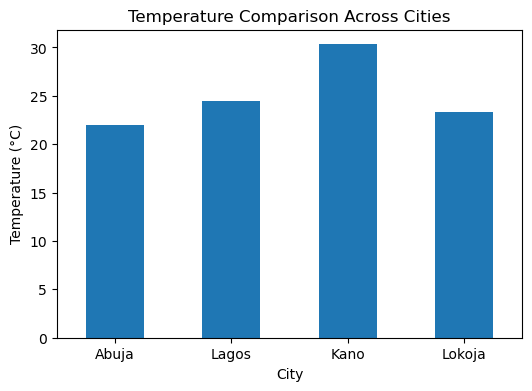

In [73]:
weather_df.plot(
    x="City",
    y="Temperature (°C)",
    kind="bar",
    legend=False,
    figsize=(6,4)
)
plt.title("Temperature Comparison Across Cities")
plt.ylabel("Temperature (°C)")
plt.xlabel("City")
plt.xticks(rotation=0)
plt.savefig("images/temperature_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

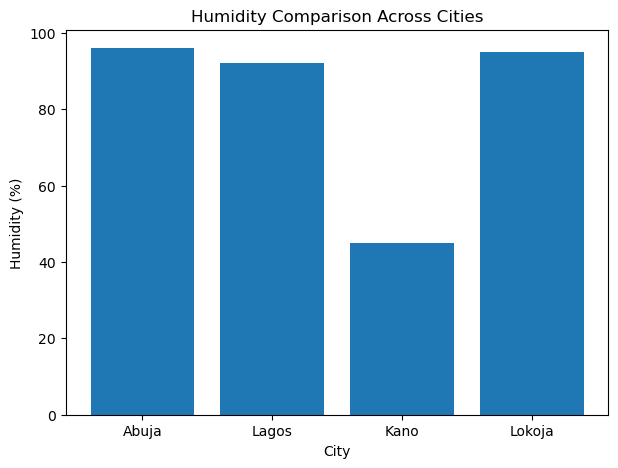

In [74]:
plt.figure(figsize=(7, 5))

plt.bar(weather_df["City"], weather_df["Humidity (%)"])

plt.title("Humidity Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Humidity (%)")
plt.savefig("images/humidity_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary of Findings

- Temperature varied across the selected cities, with **Kano** recording the highest temperature during data collection. The average temperature across all cities was 25.02°C.
- **Lokoja** recorded the highest humidity among the selected cities (96%).
- The weather conditions for the selected cities were predominantly **Overcast Clouds** at the time the data was retrieved.
- The ETL pipeline successfully extracted weather data from the OpenWeather API for multiple Nigerian cities, transformed the data into a clean and structured format using Pandas, and loaded the processed dataset into a CSV file. A simple analysis was also performed to compare weather conditions, temperature, and humidity across the selected cities.